<a href="https://colab.research.google.com/github/yjsworkbook/Telco_Customer_Churn_Logistic_Regression/blob/main/Telco_Customer_Churn_Logistic_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
df = df.drop(columns=["customerID"])

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.loc[df["TotalCharges"].isnull()]["tenure"]

,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


In [ ]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


(array([2701., 1227.,  685.,  503.,  460.,  414.,  396.,  311.,  224.,
         122.]),
 array([   0.  ,  868.48, 1736.96, 2605.44, 3473.92, 4342.4 , 5210.88,
        6079.36, 6947.84, 7816.32, 8684.8 ]),
 <BarContainer object of 10 artists>)

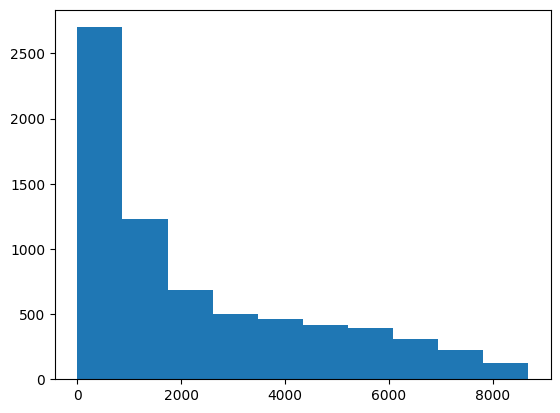

In [ ]:
plt.hist(df['TotalCharges'])

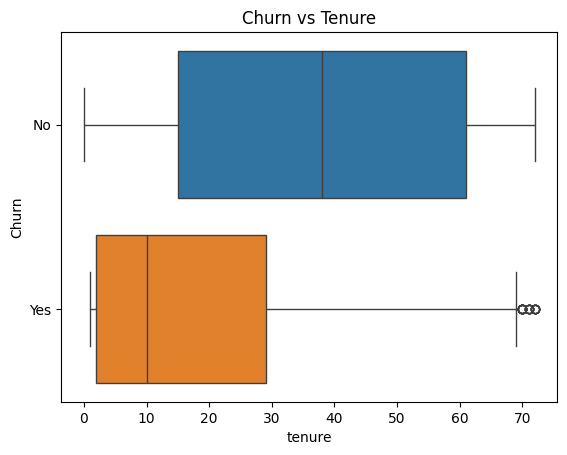

In [ ]:
sns.boxplot(x = 'tenure', y = 'Churn', data = df, hue="Churn")
plt.title("Churn vs Tenure")
plt.show()

In [ ]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


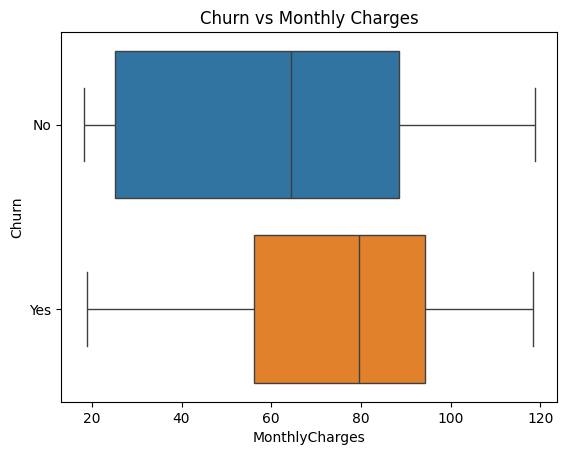

In [ ]:
sns.boxplot(x = 'MonthlyCharges', y = 'Churn', data = df, hue="Churn")
plt.title("Churn vs Monthly Charges")
plt.show()

In [ ]:
#Price sensitivity + perceived value issues.
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


<Figure size 1500x500 with 0 Axes>

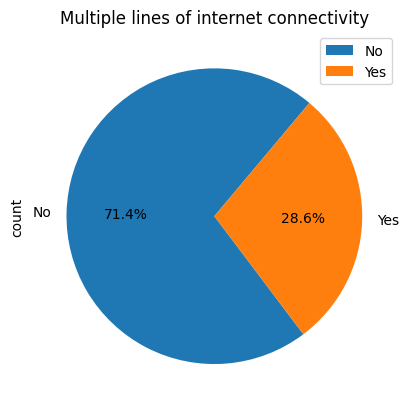

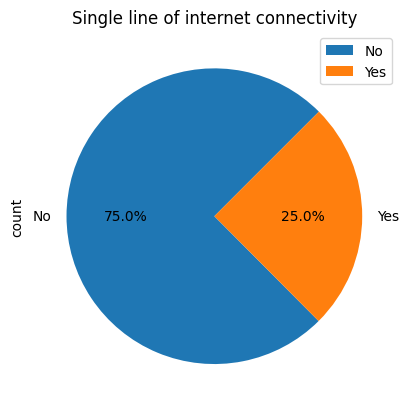

In [ ]:
plt.figure(figsize=(15,5))
pie_MultipleLines_Y = pd.DataFrame(df[df['MultipleLines'] == 'Yes']['Churn'].value_counts())
pie_MultipleLines_Y.plot.pie(subplots = True,  labels = pie_MultipleLines_Y.index.values, autopct='%1.1f%%', startangle= 50)
plt.title('Multiple lines of internet connectivity')
plt.gca().set_aspect('equal')

pie_MultipleLines_N = pd.DataFrame(df[df['MultipleLines'] == 'No']['Churn'].value_counts())
pie_MultipleLines_N.plot.pie(subplots = True,  labels = pie_MultipleLines_N.index.values, autopct='%1.1f%%', startangle= 45)
plt.title('Single line of internet connectivity')

plt.gca().set_aspect('equal')
plt.show()

*Multiple lines of internet connectivity doesn't effect churn that much.*

Text(0.5, 1.0, 'Churn vs Contract')

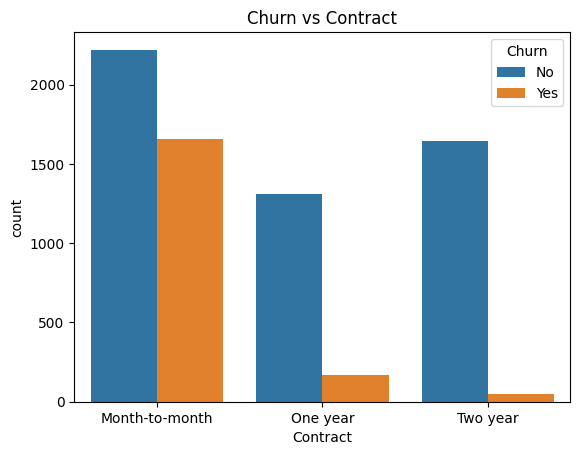

In [ ]:
sns.countplot(x=df.Contract, hue=df.Churn)
plt.title("Churn vs Contract")

In [ ]:
# Contract structure strongly influences churn risk.
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Text(0.5, 1.0, 'Churn vs Internet Service')

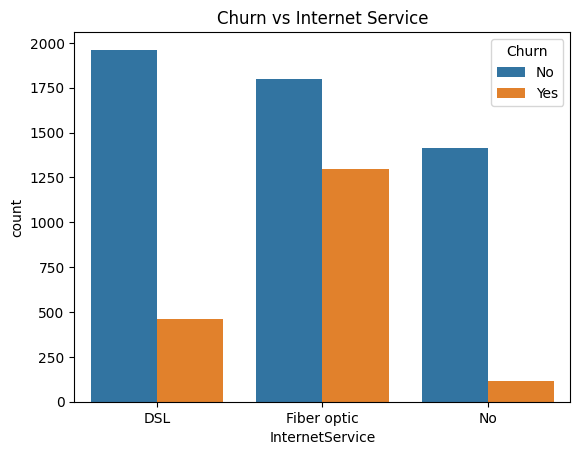

In [ ]:
sns.countplot(x=df['InternetService'], hue=df.Churn)
plt.title("Churn vs Internet Service")

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df["Churn"]

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [ ]:
# One-hot encode categoricals

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [ ]:
# df_corr = df.copy()
# df_corr['Churn_encoded'] = df_corr['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
# # Encode 'Dependents' column into numerical format
# df_corr['Dependents_encoded'] = df_corr['Dependents'].apply(lambda x: 1 if x == 'Yes' else 0)

# # Select relevant columns for correlation heatmap
# # Include numerical columns and the encoded 'Churn' and 'Dependents' columns
# correlation_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Dependents_encoded','Churn_encoded']

# correlation_matrix = df_corr[correlation_cols].corr()

# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Heatmap of Numerical Features with Churn')
# plt.show()

In [ ]:
# categorical=list(df.select_dtypes(include=['object']).columns)
# numerical=list(df.select_dtypes(include=['number']).columns)
# print(categorical)
# print(numerical)

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# categorical_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
#                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
#                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# label_encoder = LabelEncoder()
# for col in categorical_columns:
#     df[col] = label_encoder.fit_transform(df[col])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify= y, random_state=50)

**Feature scaling (required for logistic regression)**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_reg = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=51
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=51, solver='liblinear')

**Model Evaluation**


Metrics chosen:

ROC-AUC

Recall (Churn = 1)

Precision

Confusion Matrix

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)


y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, ]

In [ ]:
confusion_matrix(y_test, y_pred)

array([[911, 124],
       [175, 199]])

In [ ]:
y_pred_proba

array([[0.74499636, 0.25500364],
       [0.60220512, 0.39779488],
       [0.98394462, 0.01605538],
       ...,
       [0.75318459, 0.24681541],
       [0.99459486, 0.00540514],
       [0.40387531, 0.59612469]])

In [ ]:
roc_auc_score(y_test, y_pred_proba[:, 1])

np.float64(0.8299956082564777)

In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



### Interpretation (what you say out loud)

ROC-AUC ≈ 0.84 → strong ranking ability

Recall < Precision → some churners missed

Threshold can be tuned if business wants higher recall

### **Interpreting coefficients**

In [ ]:
coef_df = pd.DataFrame({"Feature": X.columns,
    "Coefficient": log_reg.coef_[0]}

).sort_values(by="Coefficient", ascending = False)

coef_df

,Feature,Coefficient
3,TotalCharges,0.604755
10,InternetService_Fiber optic,0.395186
26,PaperlessBilling_Yes,0.166192
28,PaymentMethod_Electronic check,0.155193
9,MultipleLines_Yes,0.132969
8,MultipleLines_No phone service,0.101903
0,SeniorCitizen,0.094560
23,StreamingMovies_Yes,0.087205
21,StreamingTV_Yes,0.074523
5,Partner_Yes,0.021804


Positive coefficient → higher churn risk


Negative coefficient → protective effect


## Final Takeaway

Using logistic regression, I identified contract type, tenure, and monthly charges as the strongest churn drivers. The model achieved a ROC-AUC of 0.84 and provides interpretable coefficients that can directly inform retention strategies, such as targeting high-risk month-to-month customers with short tenure